In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\deep-learning\datasets\Housing.csv")

In [5]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.columns.unique()

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595 entries, 0 to 594
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             595 non-null    int64 
 1   area              595 non-null    int64 
 2   bedrooms          595 non-null    int64 
 3   bathrooms         595 non-null    int64 
 4   stories           595 non-null    int64 
 5   mainroad          595 non-null    object
 6   guestroom         595 non-null    object
 7   basement          595 non-null    object
 8   hotwaterheating   595 non-null    object
 9   airconditioning   595 non-null    object
 10  parking           595 non-null    int64 
 11  prefarea          595 non-null    object
 12  furnishingstatus  595 non-null    object
dtypes: int64(6), object(7)
memory usage: 60.6+ KB


In [8]:
df.shape

(595, 13)

In [9]:
df.duplicated().sum()

0

In [10]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.950000e+02,595.000000,595.000000,595.000000,595.000000,595.000000
mean,5.078449e+06,5302.344538,3.006723,1.336134,1.878992,0.754622
std,2.123406e+06,2202.148457,0.740794,0.536187,0.918650,0.880173
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.500000e+06,3630.000000,3.000000,1.000000,1.000000,0.000000
50%,4.550000e+06,4840.000000,3.000000,1.000000,2.000000,0.000000
75%,6.215000e+06,6532.500000,3.000000,2.000000,2.000000,1.000000
max,1.335000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [11]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

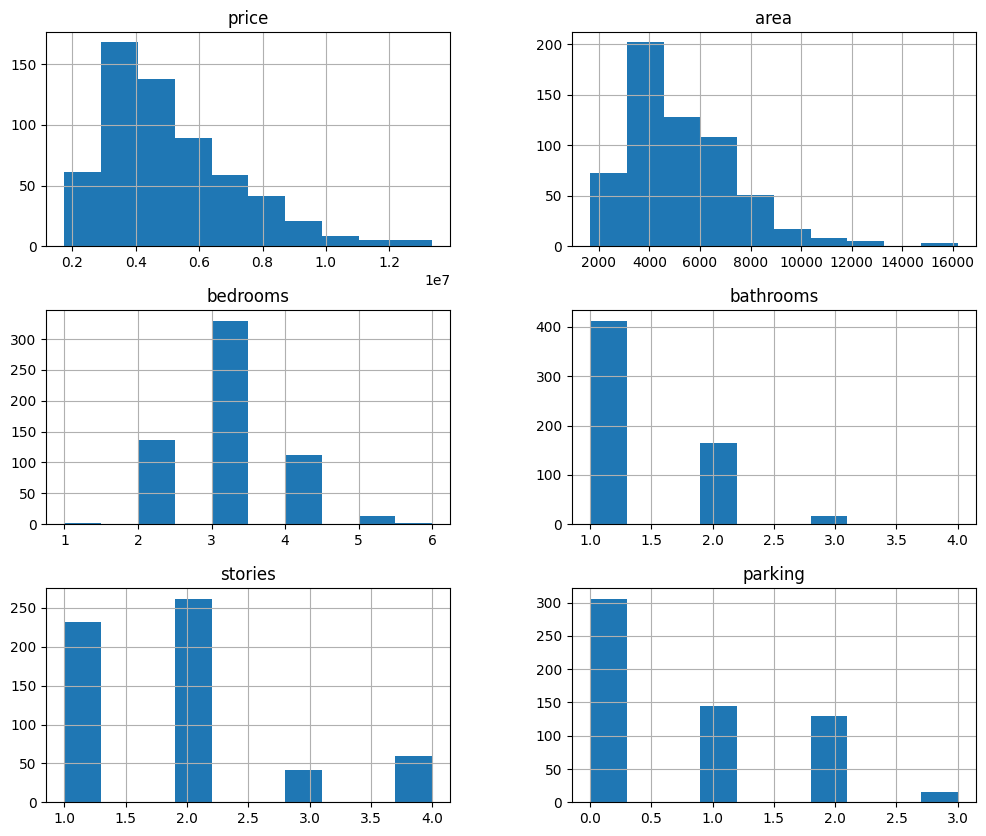

In [12]:
df.hist(figsize=(12,10))
plt.show()

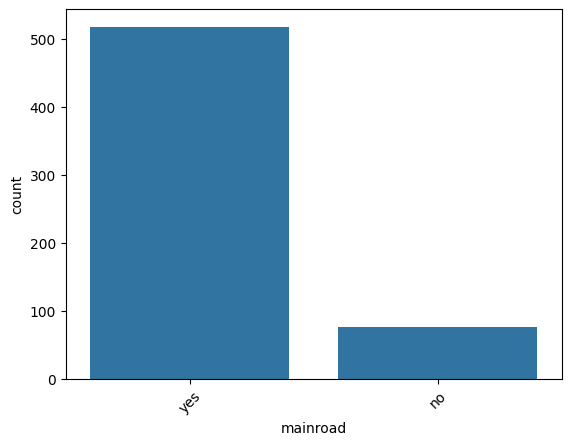

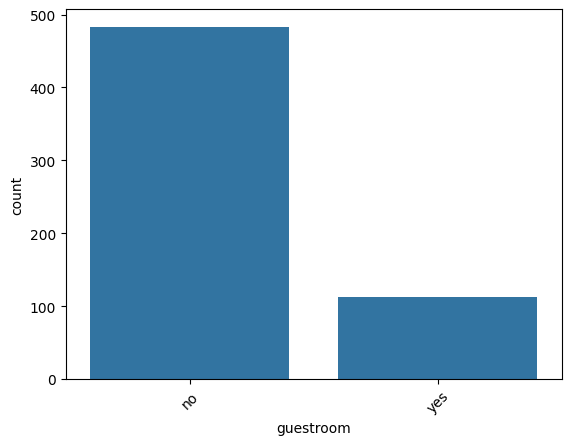

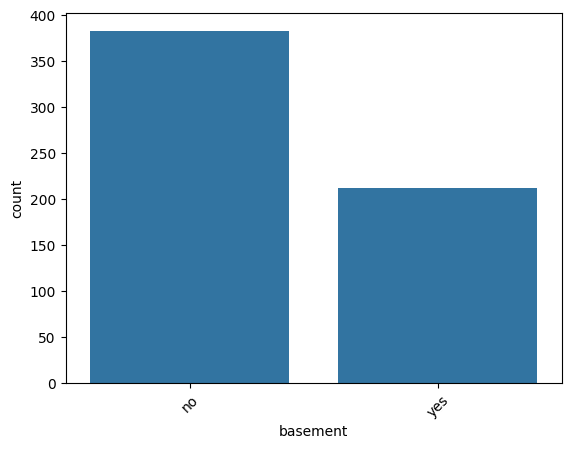

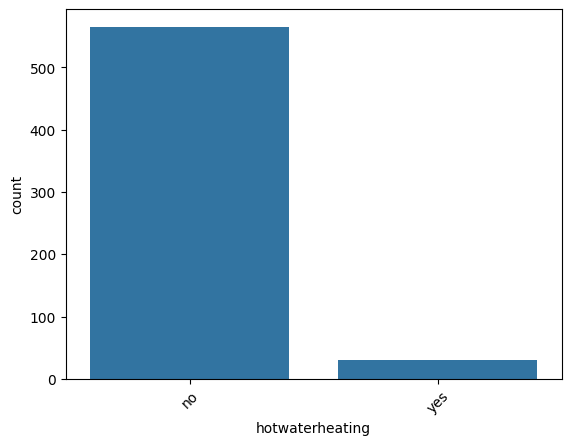

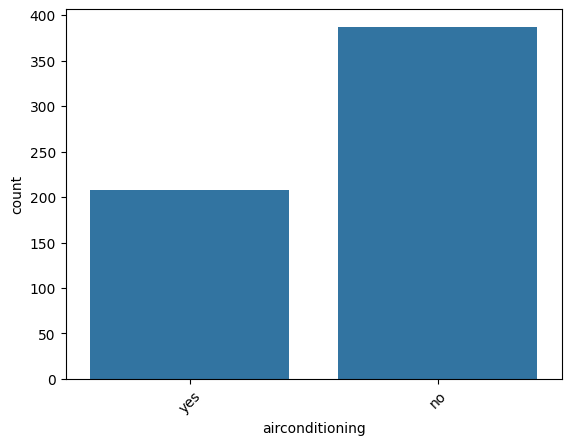

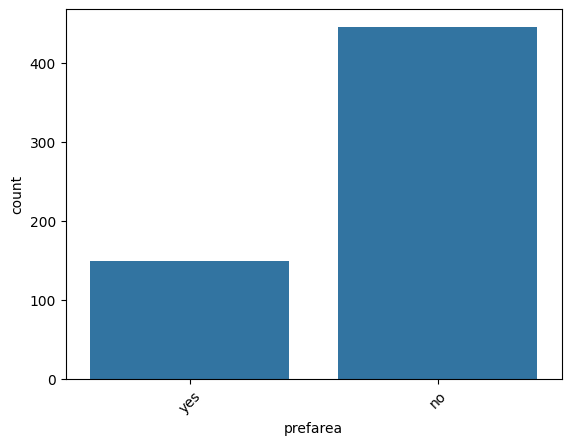

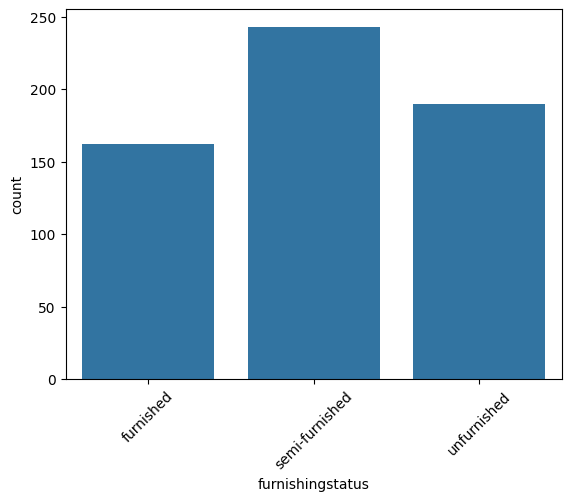

In [13]:
for col in df.select_dtypes(include='object').columns:
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.show()

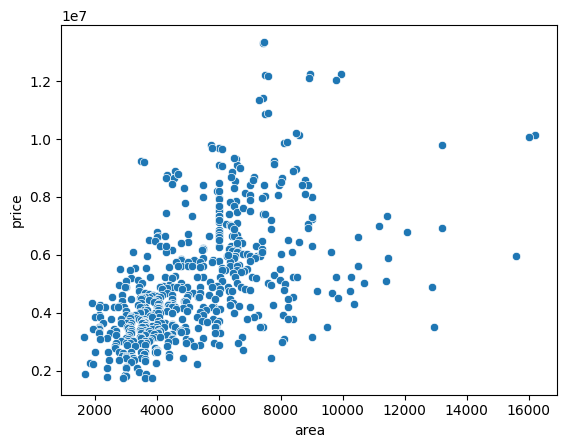

In [14]:
sns.scatterplot(x=df['area'], y=df['price'])
plt.show()

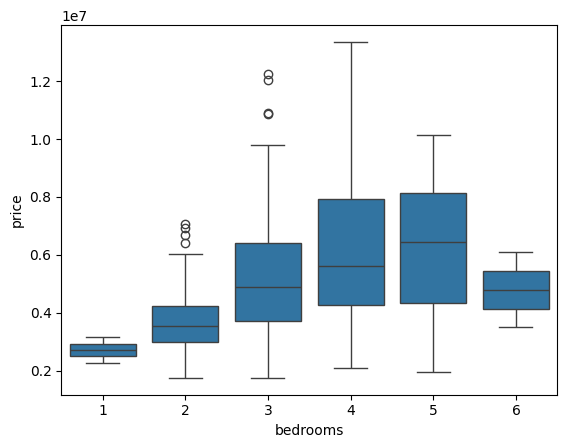

In [15]:
sns.boxplot(x=df['bedrooms'], y=df['price'])
plt.show()

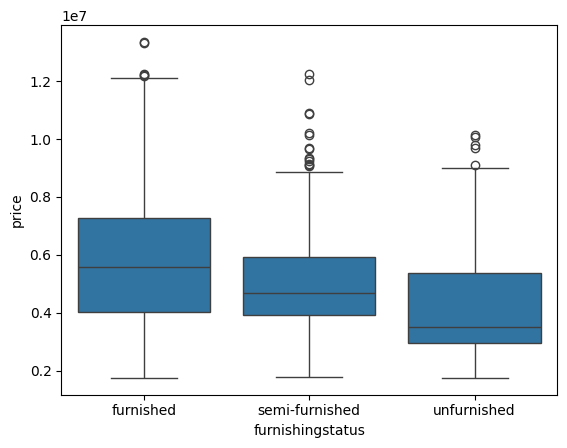

In [16]:
sns.boxplot(x=df['furnishingstatus'], y=df['price'])
plt.show()

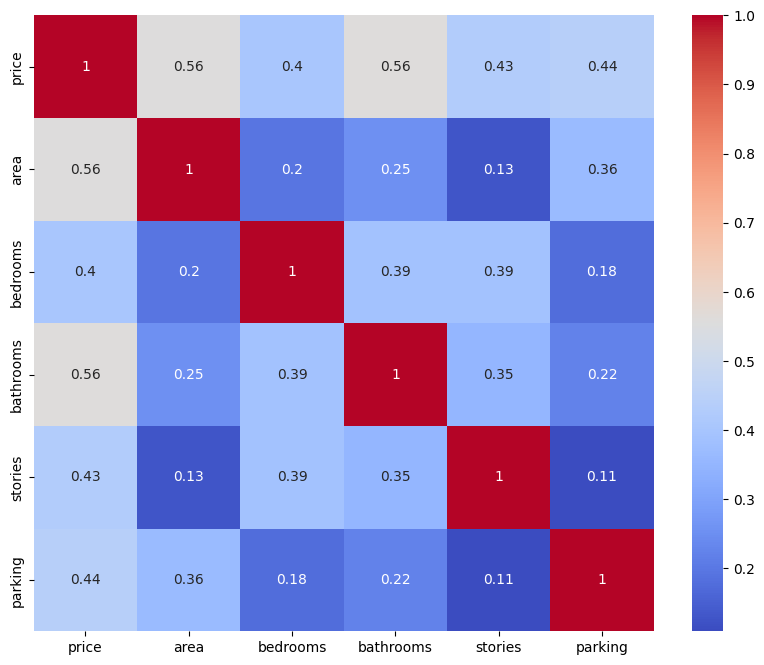

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

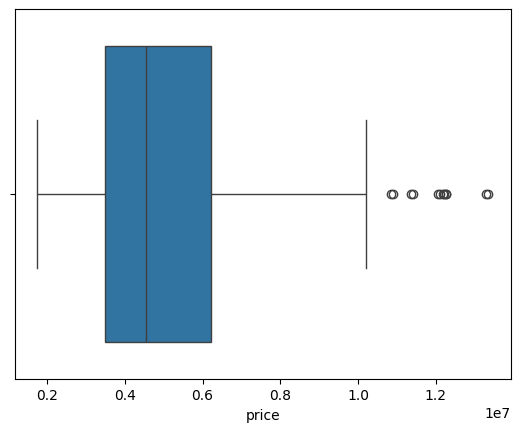

In [18]:
sns.boxplot(x=df['price'])
plt.show()

In [19]:
df['price'] = np.log(df['price'])
df['area'] = np.log(df['area'])

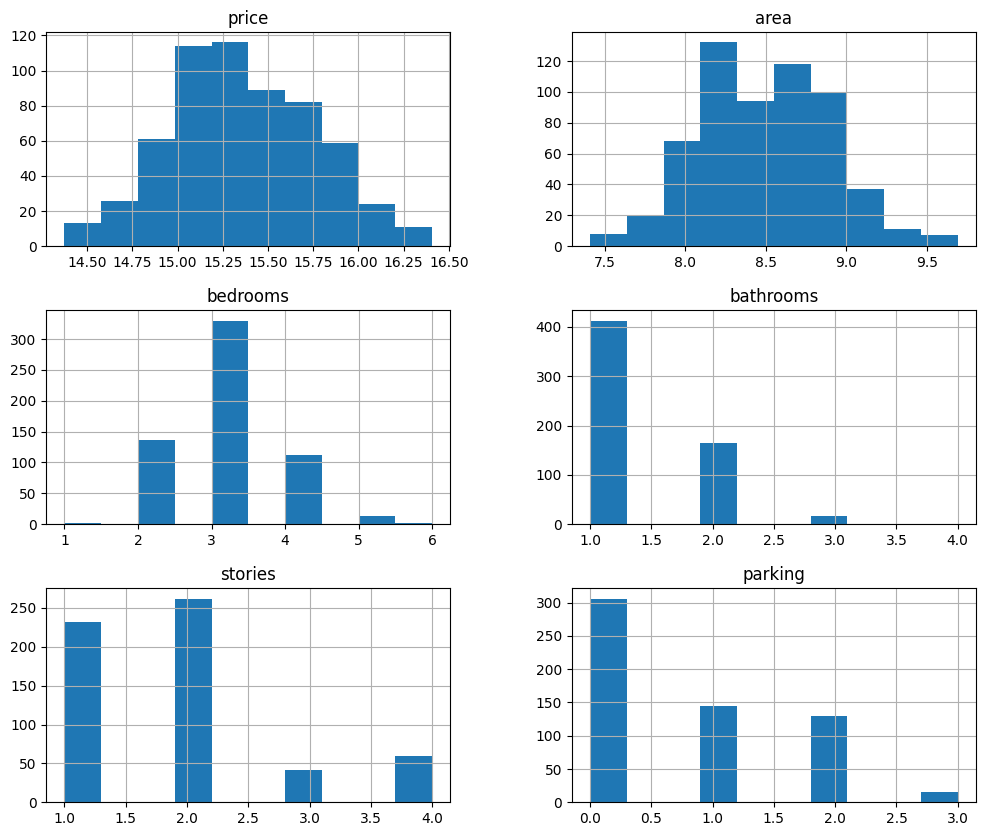

In [20]:
df.hist(figsize=(12,10))
plt.show()

In [21]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

for col in binary_cols:
    df[col] = df[col].str.strip().str.lower().map({'yes':1, 'no':0})


In [22]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,16.403275,8.911934,4,2,3,1,0,0,0,1,2,1,furnished
1,16.321036,9.100526,4,4,4,1,0,0,0,1,3,0,furnished
2,16.321036,9.206332,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,16.318175,8.922658,4,2,2,1,0,1,0,1,3,1,furnished
4,16.250001,8.911934,4,1,2,1,1,1,0,1,2,0,furnished


In [23]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [24]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [25]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,16.403275,8.911934,4,2,3,1,0,0,0,1,2,1,0,0
1,16.321036,9.100526,4,4,4,1,0,0,0,1,3,0,0,0
2,16.321036,9.206332,3,2,2,1,0,1,0,0,2,1,1,0
3,16.318175,8.922658,4,2,2,1,0,1,0,1,3,1,0,0
4,16.250001,8.911934,4,1,2,1,1,1,0,1,2,0,0,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595 entries, 0 to 594
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            595 non-null    float64
 1   area                             595 non-null    float64
 2   bedrooms                         595 non-null    int64  
 3   bathrooms                        595 non-null    int64  
 4   stories                          595 non-null    int64  
 5   mainroad                         595 non-null    int64  
 6   guestroom                        595 non-null    int64  
 7   basement                         595 non-null    int64  
 8   hotwaterheating                  595 non-null    int64  
 9   airconditioning                  595 non-null    int64  
 10  parking                          595 non-null    int64  
 11  prefarea                         595 non-null    int64  
 12  furnishingstatus_semi-

In [27]:
df.corr()['price']

price                              1.000000
area                               0.606028
bedrooms                           0.405485
bathrooms                          0.533333
stories                            0.434622
mainroad                           0.342402
guestroom                          0.272488
basement                           0.211079
hotwaterheating                    0.104945
airconditioning                    0.480143
parking                            0.424488
prefarea                           0.344310
furnishingstatus_semi-furnished    0.083397
furnishingstatus_unfurnished      -0.320254
Name: price, dtype: float64

In [28]:
X = df.drop('price', axis=1)
y = df['price'].values

In [29]:
X.shape

(595, 13)

In [30]:
y.shape

(595,)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
)

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# y_train = scaler.transform(y_train)
# y_test = scaler.transform(y_test)

In [53]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=13))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='linear'))

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 128)               1792      
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_16 (Dense)            (None, 32)                4128      
                                                                 
 dense_17 (Dense)            (None, 1)                 33        
                                                                 
Total params: 5,953
Trainable params: 5,953
Non-trainable params: 0
_________________________________________________________________


In [54]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [55]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5, 
    min_delta=0.02,
    restore_best_weights=True
)

In [56]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
15/15 [==============================] - 1s 20ms/step - loss: 213.8770 - mae: 14.6060 - val_loss: 188.0689 - val_mae: 13.6928
Epoch 2/50
15/15 [==============================] - 0s 9ms/step - loss: 167.0074 - mae: 12.8810 - val_loss: 136.1679 - val_mae: 11.6122
Epoch 3/50
15/15 [==============================] - 0s 9ms/step - loss: 111.6461 - mae: 10.4395 - val_loss: 78.0392 - val_mae: 8.6800
Epoch 4/50
15/15 [==============================] - 0s 9ms/step - loss: 57.0927 - mae: 7.2837 - val_loss: 30.2958 - val_mae: 5.0889
Epoch 5/50
15/15 [==============================] - 0s 8ms/step - loss: 19.4867 - mae: 3.8698 - val_loss: 8.7628 - val_mae: 2.4551
Epoch 6/50
15/15 [==============================] - 0s 7ms/step - loss: 6.7446 - mae: 2.1451 - val_loss: 5.6015 - val_mae: 1.8533
Epoch 7/50
15/15 [==============================] - 0s 6ms/step - loss: 4.5505 - mae: 1.7046 - val_loss: 4.2879 - val_mae: 1.5789
Epoch 8/50
15/15 [==============================] - 0s 9ms/step - loss

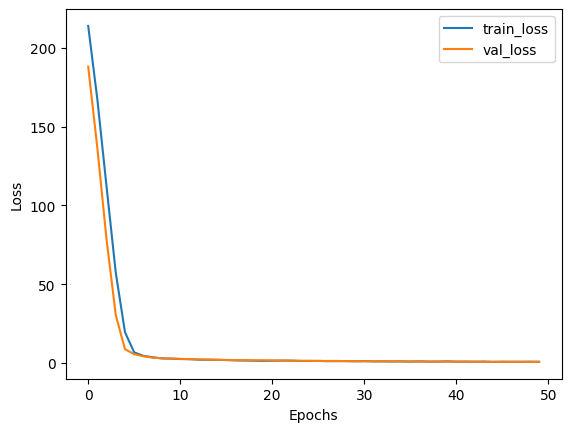

In [57]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [58]:
# Predict
y_pred = model.predict(X_test)

# Convert back to actual price
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

4/4 [==============================] - 1s 4ms/step


In [61]:
from sklearn.metrics import mean_absolute_error

log_mae = mean_absolute_error(y_test, y_pred)

print("Log MAE:", log_mae)

Log MAE: 0.5933943588193342


In [62]:
percentage_error = (np.exp(log_mae) - 1) * 100
print("Approx % Error:", percentage_error)

Approx % Error: 81.01222036354494


In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

log_mae = mean_absolute_error(y_test, y_pred)

percentage_error = (np.exp(log_mae) - 1) * 100

print("RF % Error:", percentage_error)

RF % Error: 17.917531668317753
